In [1]:
import pickle
import os
import matplotlib.pyplot as plt

In [11]:
# 필요한 함수들 정의
from tqdm import tqdm
import time
import numpy as np
import random
import hnswlib
from tqdm import tqdm
import time
import json
import os 
import matplotlib.pyplot as plt
# 데이터셋 불러오는 블록
####################################################################
# dataset_name ="sift1m"
dataset_name_list =["mtg-40K", "HnM", "ArXiv", "sift1m1", "sift1m2" , "sift1m3","sift1m4","sift1m5"]
# dataset_name_list =["HnM", "ArXiv", "sift1m1"]
# dataset_name ="ArXiv"

# num_attribute = 3
# cardinality = [6] * num_attribute
# distribution = "random"
# distribution = "zipf"

# sort_hardness = "Hardness"
# sort_hardness = "Pre_Hardness"
# sort_hardness = "Post_Hardness"


# sort_hardness = "selectivity"
# sort_hardness = "correlation"
# sort_hardness = "select_corr_combine"
##################################################################################################

def satisfies_conditions(payload, conditions):
    if "and" in conditions:
        for cond in conditions["and"]:
            # cond는 단일 dict: {label: {match: {value: ...}}}
            if not isinstance(cond, dict):
                continue
            for key, rule in cond.items():
                if "match" in rule and "value" in rule["match"]:
                    if payload.get(key) != rule["match"]["value"]:
                        return False
                else:
                    # 지원하지 않는 조건
                    return False
        return True
    else:
        # "and" 키가 없으면 조건 없음 → 항상 True
        return True

def post_filtering(index, K, tests, payloads, K_n, space):
    """
    index: hnswlib index
    K: top-K
    tests: batch 단위 리스트 (길이: 1000)
    payloads: 전체 데이터셋 메타데이터 리스트 (len = index에 들어간 벡터 개수)
    ---
    return: 각 쿼리별 post-filtering 결과 (리스트 of id 리스트)
    """
    results = []
    # batch knn-query (각 쿼리 vector를 모아서 한 번에 처리)
    queries = [t['query'] for t in tests]
    # 후보 pool을 넉넉히 잡자 (예: K*10)
    labels, dists = index.knn_query(queries, k=K*K_n)
    for i, test in enumerate(tests):
        # print(test["conditions"])
        conditions = test['conditions']
        filtered = []
        for idx in labels[i]:
            if satisfies_conditions(payloads[idx], conditions):
                filtered.append(idx)
            if len(filtered) == K:
                break
        results.append(filtered)
    return results


def recall_at_k(retrieved, gt, k):
    if not gt:
        return 0.0
    return len(set(retrieved[:k]) & set(gt)) / min(len(gt), k)


trade_off = {}

for dataset_name in dataset_name_list:
    if dataset_name == "sift1m1":
        # cardi = '_'.join(str(c) for c in cardinality)
        dataset_name_1 = "sift1m"
        num_attribute = 3
        cardinality = [3,2,2]
        distribution = "zipf"
        cardi = '_'.join(str(c) for c in cardinality)
        dataset_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name_1}_A{num_attribute}_{cardi}_{distribution}"
    elif dataset_name == "sift1m2":
        # cardi = '_'.join(str(c) for c in cardinality)
        dataset_name_1 = "sift1m"
        num_attribute = 12
        cardinality = [1] * num_attribute
        distribution = "zipf"
        cardi = '_'.join(str(c) for c in cardinality)
        dataset_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name_1}_A{num_attribute}_{cardi}_{distribution}"
    elif dataset_name == "sift1m3":
        # cardi = '_'.join(str(c) for c in cardinality)
        dataset_name_1 = "sift1m"
        num_attribute = 1
        cardinality = [12] * num_attribute
        distribution = "zipf"
        cardi = '_'.join(str(c) for c in cardinality)
        dataset_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name_1}_A{num_attribute}_{cardi}_{distribution}"
    # elif dataset_name == "sift1m4":
    #     # cardi = '_'.join(str(c) for c in cardinality)
    #     dataset_name_1 = "sift1m"
    #     num_attribute = 2
    #     cardinality = [3] * num_attribute
    #     distribution = "random"
    #     cardi = '_'.join(str(c) for c in cardinality)
    #     dataset_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name_1}_A{num_attribute}_{cardi}_{distribution}"
    # elif dataset_name == "sift1m5":
    #     # cardi = '_'.join(str(c) for c in cardinality)
    #     dataset_name_1 = "sift1m"
    #     num_attribute = 2
    #     cardinality = [3] * num_attribute
    #     distribution = "zipf"
    #     cardi = '_'.join(str(c) for c in cardinality)
    #     dataset_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name_1}_A{num_attribute}_{cardi}_{distribution}"
    elif dataset_name == "HnM" or dataset_name == "mtg-40K":
        dataset_path = f"/home/mintaek/hybrid_index/Benchmark/{dataset_name}"

    elif dataset_name == "ArXiv":
        dataset_path = f"/home/mintaek/hybrid_index/Benchmark/ArXiv/medium/include"

    DATA_DIR = os.path.join(dataset_path, "hardness_format")


    vectors_file = f"{DATA_DIR}/vectors.npy"
    # print("vector file path", vectors_file)
    payloads_file = f"{DATA_DIR}/payloads.jsonl"
    tests_file = f"{DATA_DIR}/tests.jsonl"

    # ------------------------------------
    # 1. Load vectors.npy
    # ------------------------------------
    vectors = np.load(vectors_file)
    print("vectors.shape =", vectors.shape)

    # ------------------------------------
    # 2. Load payloads.jsonl
    # ------------------------------------
    payloads = []
    with open(payloads_file, "r") as f:
        for line in f:
            payloads.append(json.loads(line))

    print(f"Loaded {len(payloads)} payloads")

    # ------------------------------------
    # 3. Load tests.jsonl
    # ------------------------------------
    tests = []
    with open(tests_file, "r") as f:
        for line in f:
            tests.append(json.loads(line))

    print(f"Loaded {len(tests)} tests")

    # # ------------------------------------
    # # 예시 출력
    # print("\nSample payload:", payloads[0])
    # print("\nSample test:", tests[0])




    # 1. Load hardness and GT
    space = "l2"
    # space = "cosine"

    ## post filtering 측정하기
    index = hnswlib.Index(space=space, dim=len(vectors[0]))
    index.init_index(max_elements=len(vectors), ef_construction=50, M=8)
    index.add_items(vectors, num_threads=32)

    if dataset_name == "HnM":
        K = 25  # top-K
    else:
        K = 10
    trade_off[dataset_name] = {}
    for K_n in tqdm([5, 10, 20, 50, 100]):
        t0 = time.time()
        results = post_filtering(index, K, tests, payloads, K_n, space)
        t1 = time.time()
        elapsed = t1 - t0
        recalls = []
        for i, test in enumerate(tests):
            gt_ids = test['closest_ids']
            retrieved_ids = results[i]

            # gt에서 4294967295 제거
            valid_gt_ids = [gt for gt in gt_ids if gt != 4294967295]

            # valid_gt가 없으면 recall 정의 불가 → 0으로 처리
            if len(valid_gt_ids) == 0:
                continue
            else:
                recalls.append(recall_at_k(retrieved_ids, valid_gt_ids, K))
        avg_recall = np.mean(recalls)
        qps = len(tests) / elapsed if elapsed > 0 else 0
        # print(f"Batch {batch_idx}: QPS={qps:.2f}, Avg Recall@{K}={avg_recall:.4f}, Time={elapsed:.2f}s")
        stats = {
            'qps': qps,
            'avg_recall': avg_recall,
            'elapsed': elapsed,
            'num_queries': len(tests)
        }
        trade_off[dataset_name][K_n] = stats





import pickle
with open(os.path.join("/home/mintaek/hybrid_index/methods/Post_Pre_Filtering", "trade_off_reference.pkl"), "wb") as f:
    pickle.dump(trade_off, f)



vectors.shape = (40274, 1152)
Loaded 40274 payloads
Loaded 10000 tests


100%|██████████| 5/5 [00:41<00:00,  8.35s/it]


vectors.shape = (105100, 2048)
Loaded 105100 payloads
Loaded 10000 tests


100%|██████████| 5/5 [02:26<00:00, 29.30s/it]


vectors.shape = (100000, 4096)
Loaded 100000 payloads
Loaded 10000 tests


...

100%|██████████| 5/5 [00:46<00:00,  9.23s/it]


vectors.shape = (1000000, 128)
Loaded 1000000 payloads
Loaded 10000 tests


100%|██████████| 5/5 [00:36<00:00,  7.27s/it]


vectors.shape = (1000000, 128)
Loaded 1000000 payloads
Loaded 10000 tests


100%|██████████| 5/5 [00:27<00:00,  5.55s/it]


In [12]:
file_path = os.path.join(
    "/home/mintaek/hybrid_index/methods/Post_Pre_Filtering",
    "trade_off.pkl"
)

with open(file_path, "rb") as f:
    trade_off1 = pickle.load(f)

file_path = os.path.join(
    "/home/mintaek/hybrid_index/methods/Post_Pre_Filtering",
    "trade_off_new.pkl"
)

with open(file_path, "rb") as f:
    trade_off2 = pickle.load(f)

file_path = os.path.join(
    "/home/mintaek/hybrid_index/methods/Post_Pre_Filtering",
    "trade_off_reference.pkl"
)

with open(file_path, "rb") as f:
    trade_off = pickle.load(f)
    

In [13]:
# trade_off1
merged = {**trade_off1,**trade_off2, **trade_off}
print(merged[(12,1,"zipf")])
print(merged["sift1m2"])

{5: {'qps': 10473.12417568204, 'avg_recall': np.float64(0.14212000000000002), 'elapsed': 0.9548249244689941, 'num_queries': 10000}, 10: {'qps': 2107.8506065385473, 'avg_recall': np.float64(0.25037000000000004), 'elapsed': 4.744169235229492, 'num_queries': 10000}, 20: {'qps': 2230.661911315332, 'avg_recall': np.float64(0.40034000000000003), 'elapsed': 4.482974290847778, 'num_queries': 10000}, 50: {'qps': 1471.7790332726734, 'avg_recall': np.float64(0.63549), 'elapsed': 6.7944982051849365, 'num_queries': 10000}, 100: {'qps': 1088.126882275721, 'avg_recall': np.float64(0.7936000000000001), 'elapsed': 9.190104722976685, 'num_queries': 10000}}
{5: {'qps': 3575.6286989815057, 'avg_recall': np.float64(0.14278), 'elapsed': 2.796710968017578, 'num_queries': 10000}, 10: {'qps': 2414.8956364547735, 'avg_recall': np.float64(0.25076000000000004), 'elapsed': 4.140965700149536, 'num_queries': 10000}, 20: {'qps': 1320.8586634395626, 'avg_recall': np.float64(0.40181), 'elapsed': 7.5708327293396, 'num_q

/tmp/ipykernel_144094/1594995941.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(merged))


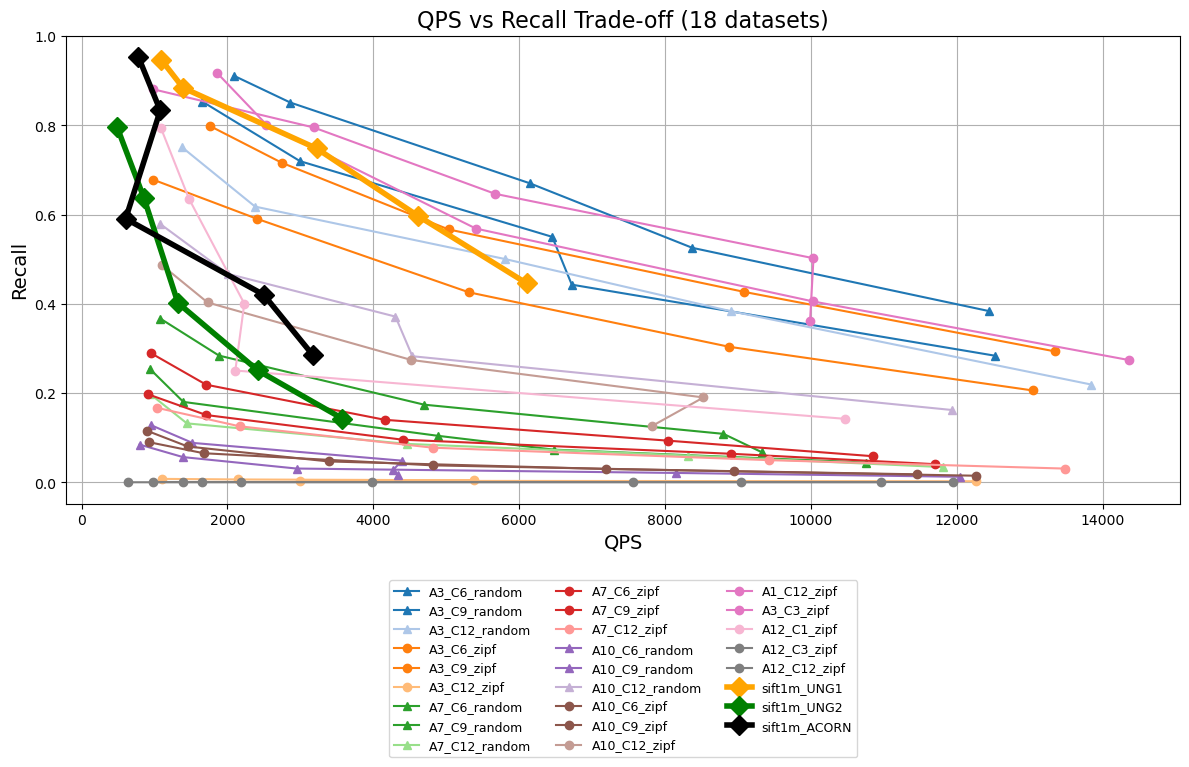

In [14]:
plt.figure(figsize=(12, 8))

# 색상 팔레트 준비 (18개 데이터셋 대비)
cmap = plt.cm.get_cmap("tab20", len(merged))

for idx, (dataset_key, stats_dict) in enumerate(merged.items()):
    if dataset_key == "HnM":
        # # HnM 전용 스타일 (빨간색 선)
        # K_ns = sorted(int(k) for k in stats_dict.keys())
        # qps_values = [stats_dict[k]["qps"] for k in K_ns]
        # recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        # plt.plot(
        #     qps_values,
        #     recall_values,
        #     marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
        #     markersize = "10",
        #     label="HnM",
        #     color="red",
        #     linewidth=4.0
        # )
        pass
    elif dataset_key == "ArXiv":
        # HnM 전용 스타일 (빨간색 선)
        # K_ns = sorted(int(k) for k in stats_dict.keys())
        # qps_values = [stats_dict[k]["qps"] for k in K_ns]
        # recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        # plt.plot(
        #     qps_values,
        #     recall_values,
        #     marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
        #     markersize = "10",
        #     label="ArXiv",
        #     color="Blue",
        #     linewidth=4.0
        # )
        pass
    elif dataset_key == "mtg-40K":
        # HnM 전용 스타일 (빨간색 선)
        # K_ns = sorted(int(k) for k in stats_dict.keys())
        # qps_values = [stats_dict[k]["qps"] for k in K_ns]
        # recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        # plt.plot(
        #     qps_values,
        #     recall_values,
        #     marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
        #     markersize = "10",
        #     label="ArXiv",
        #     color="Blue",
        #     linewidth=4.0
        # )
        pass
    elif dataset_key == "sift1m1":
        # HnM 전용 스타일 (빨간색 선)
        K_ns = sorted(int(k) for k in stats_dict.keys())
        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        plt.plot(
            qps_values,
            recall_values,
            marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
            markersize = "10",
            label="sift1m_UNG1",
            color="Orange",
            linewidth=4.0
        )
    elif dataset_key == "sift1m2":
        # HnM 전용 스타일 (빨간색 선)
        K_ns = sorted(int(k) for k in stats_dict.keys())
        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        plt.plot(
            qps_values,
            recall_values,
            marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
            markersize = "10",
            label="sift1m_UNG2",
            color="Green",
            linewidth=4.0
        )
    elif dataset_key == "sift1m3":
        # HnM 전용 스타일 (빨간색 선)
        K_ns = sorted(int(k) for k in stats_dict.keys())
        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        plt.plot(
            qps_values,
            recall_values,
            marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
            markersize = "10",
            label="sift1m_ACORN",
            color="Black",
            linewidth=4.0
        )
    elif dataset_key == "sift1m4":
        # # HnM 전용 스타일 (빨간색 선)
        # K_ns = sorted(int(k) for k in stats_dict.keys())
        # qps_values = [stats_dict[k]["qps"] for k in K_ns]
        # recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        # plt.plot(
        #     qps_values,
        #     recall_values,
        #     marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
        #     markersize = "10",
        #     label="sift1m_simple1",
        #     color="Pink",
        #     linewidth=4.0
        # )
        pass
    elif dataset_key == "sift1m5":
        # # HnM 전용 스타일 (빨간색 선)
        # K_ns = sorted(int(k) for k in stats_dict.keys())
        # qps_values = [stats_dict[k]["qps"] for k in K_ns]
        # recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        # plt.plot(
        #     qps_values,
        #     recall_values,
        #     marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
        #     markersize = "10",
        #     label="sift1m_simple2",
        #     color="Purple",
        #     linewidth=4.0
        # )
        pass
    else:
        num_attr, card, dist = dataset_key

        # distribution별 마커 선택
        if dist == "zipf":
            marker = "o"   # 동그라미
        elif dist == "random":
            marker = "^"   # 세모
        else:
            marker = "s"   # 혹시 모르는 경우 사각형

        K_ns = sorted(int(k) for k in stats_dict.keys())
        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        plt.plot(
            qps_values,
            recall_values,
            marker=marker,
            label=f"A{num_attr}_C{card}_{dist}",
            color=cmap(idx)
        )


plt.xlabel("QPS", fontsize=14)
plt.ylabel("Recall", fontsize=14)
plt.title("QPS vs Recall Trade-off (18 datasets)", fontsize=16)
plt.legend(
    fontsize=9,
    ncol=3,
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center"
)
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_144094/2310330611.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(merged))


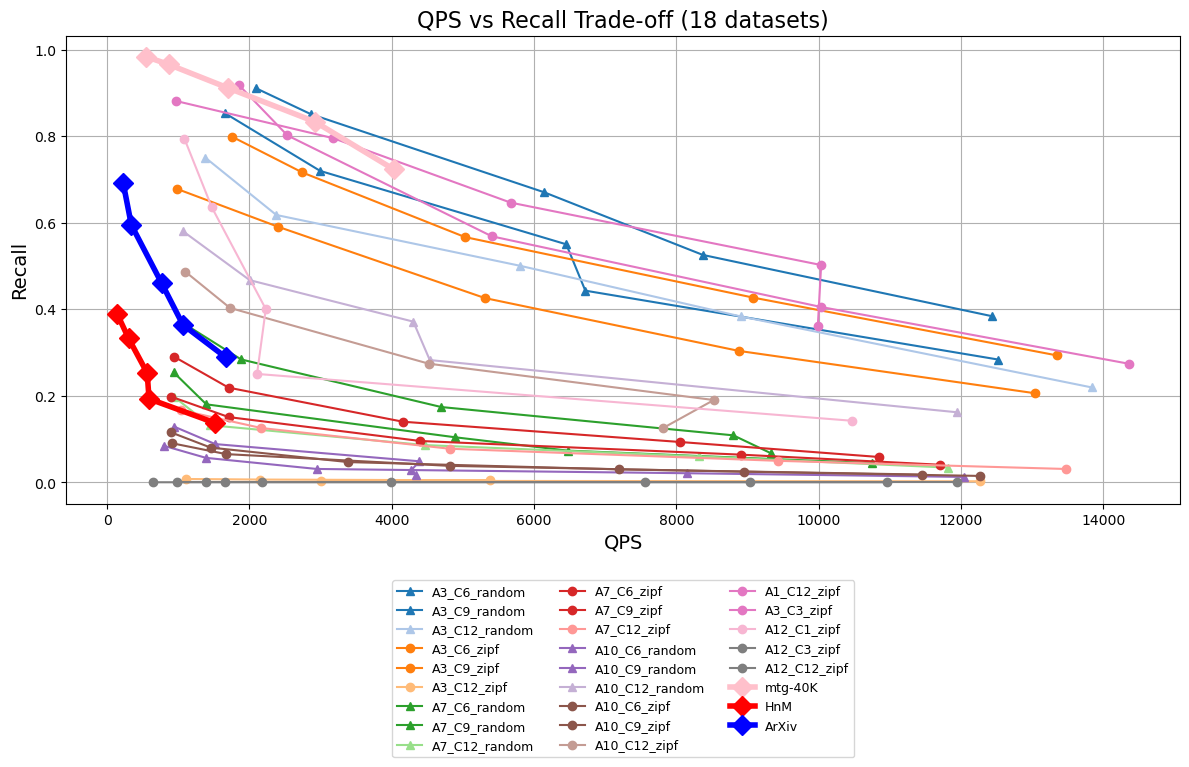

In [15]:




plt.figure(figsize=(12, 8))

# 색상 팔레트 준비 (18개 데이터셋 대비)
cmap = plt.cm.get_cmap("tab20", len(merged))

for idx, (dataset_key, stats_dict) in enumerate(merged.items()):
    if dataset_key == "HnM":
        # HnM 전용 스타일 (빨간색 선)
        K_ns = sorted(int(k) for k in stats_dict.keys())
        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        plt.plot(
            qps_values,
            recall_values,
            marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
            markersize = "10",
            label="HnM",
            color="red",
            linewidth=4.0
        )
    elif dataset_key == "ArXiv":
        # HnM 전용 스타일 (빨간색 선)
        K_ns = sorted(int(k) for k in stats_dict.keys())
        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        plt.plot(
            qps_values,
            recall_values,
            marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
            markersize = "10",
            label="ArXiv",
            color="Blue",
            linewidth=4.0
        )
    elif dataset_key == "mtg-40K":
        # HnM 전용 스타일 (빨간색 선)
        K_ns = sorted(int(k) for k in stats_dict.keys())
        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        plt.plot(
            qps_values,
            recall_values,
            marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
            markersize = "10",
            label="mtg-40K",
            color="Pink",
            linewidth=4.0
        )
    elif dataset_key == "sift1m1":
        # # HnM 전용 스타일 (빨간색 선)
        # K_ns = sorted(int(k) for k in stats_dict.keys())
        # qps_values = [stats_dict[k]["qps"] for k in K_ns]
        # recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        # plt.plot(
        #     qps_values,
        #     recall_values,
        #     marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
        #     markersize = "10",
        #     label="sift1m_UNG1",
        #     color="Orange",
        #     linewidth=4.0
        # )
        pass
    elif dataset_key == "sift1m2":
        # HnM 전용 스타일 (빨간색 선)
        # K_ns = sorted(int(k) for k in stats_dict.keys())
        # qps_values = [stats_dict[k]["qps"] for k in K_ns]
        # recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        # plt.plot(
        #     qps_values,
        #     recall_values,
        #     marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
        #     markersize = "10",
        #     label="sift1m_UNG2",
        #     color="Green",
        #     linewidth=4.0
        # )
        pass
    elif dataset_key == "sift1m3":
        # HnM 전용 스타일 (빨간색 선)
        # K_ns = sorted(int(k) for k in stats_dict.keys())
        # qps_values = [stats_dict[k]["qps"] for k in K_ns]
        # recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        # plt.plot(
        #     qps_values,
        #     recall_values,
        #     marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
        #     markersize = "10",
        #     label="sift1m_ACORN",
        #     color="Black",
        #     linewidth=4.0
        # )
        pass
    elif dataset_key == "sift1m4":
        # HnM 전용 스타일 (빨간색 선)
        # K_ns = sorted(int(k) for k in stats_dict.keys())
        # qps_values = [stats_dict[k]["qps"] for k in K_ns]
        # recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        # plt.plot(
        #     qps_values,
        #     recall_values,
        #     marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
        #     markersize = "10",
        #     label="sift1m_simple1",
        #     color="Pink",
        #     linewidth=4.0
        # )
        pass
    elif dataset_key == "sift1m5":
        # HnM 전용 스타일 (빨간색 선)
        # K_ns = sorted(int(k) for k in stats_dict.keys())
        # qps_values = [stats_dict[k]["qps"] for k in K_ns]
        # recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        # plt.plot(
        #     qps_values,
        #     recall_values,
        #     marker="D",  # 다이아몬드 마커 (눈에 잘 띄게)
        #     markersize = "10",
        #     label="sift1m_simple2",
        #     color="Purple",
        #     linewidth=4.0
        # )
        pass
    else:
        num_attr, card, dist = dataset_key

        # distribution별 마커 선택
        if dist == "zipf":
            marker = "o"   # 동그라미
        elif dist == "random":
            marker = "^"   # 세모
        else:
            marker = "s"   # 혹시 모르는 경우 사각형

        K_ns = sorted(int(k) for k in stats_dict.keys())
        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        plt.plot(
            qps_values,
            recall_values,
            marker=marker,
            label=f"A{num_attr}_C{card}_{dist}",
            color=cmap(idx)
        )


plt.xlabel("QPS", fontsize=14)
plt.ylabel("Recall", fontsize=14)
plt.title("QPS vs Recall Trade-off (18 datasets)", fontsize=16)
plt.legend(
    fontsize=9,
    ncol=3,
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center"
)
plt.grid(True)
plt.tight_layout()
plt.show()
